In [1]:
# To open excel data, we'll first need to install an extra package dependency
!pip install openpyxl -qq

# Import the libary - you only have to do this once per file
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
filepath2 = './HydroData/dailydata2026.csv'
filepath1 = './HydroData/dailydata2025.csv'

In [18]:
insitu2 =  pd.read_csv(filepath1)
insitu1 =  pd.read_csv(filepath2)

In [19]:
datasets = [insitu1, insitu2]
years = [2025, 2026]

new_colnames = {'DATE': 'Date',
    'PRCP': 'Precipitation',
    'SNOW': 'Snow Fall',
    'SNWD': 'Snow Depth'}

for i in range(len(datasets)):
    datasets[i] = datasets[i][['DATE', 'PRCP', 'SNOW', 'SNWD']].copy()
    datasets[i] = datasets[i].rename(columns=new_colnames)
    datasets[i]['Date'] = pd.to_datetime(datasets[i]['Date'])
    datasets[i] = datasets[i].set_index('Date')    

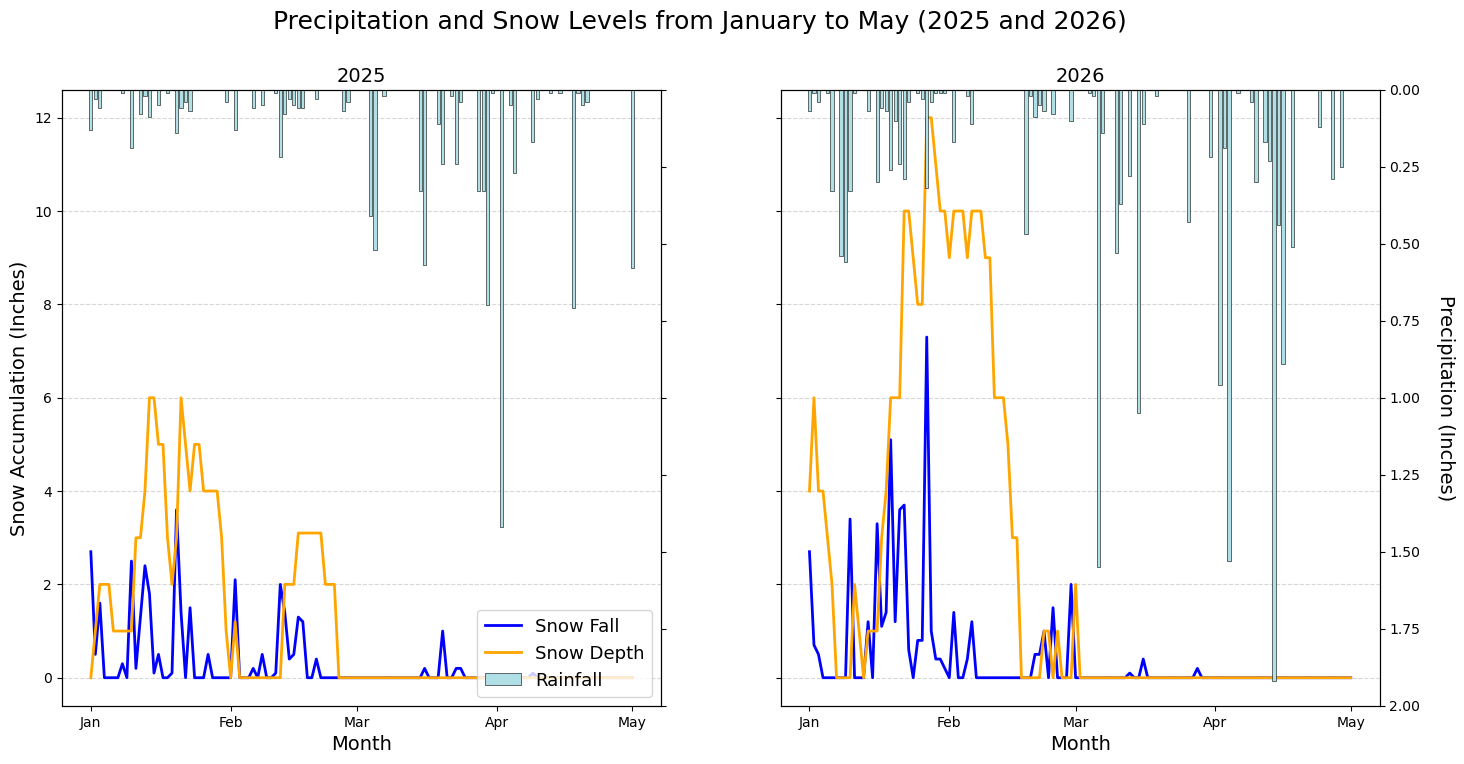

In [64]:
fig, axes = plt.subplots(1,2, figsize=(17,8), sharey=True)
fig.suptitle('Precipitation and Snow Levels from January to May (2025 and 2026)', fontsize=18)

for i in range (2):
    ax = axes[i]
    data = datasets[i]
    year = years[i]

    snowFall = ax.plot(data.index, data['Snow Fall'], label = 'Snow Fall', color = 'blue', linewidth = 2)
    SnowDepth = ax.plot(data.index, data['Snow Depth'], label = 'Snow Depth', color = 'orange', linewidth = 2)
    ax.set_title(f'{year}', fontsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.5)
    if i == 0:
        ax.set_ylabel('Snow Accumulation (Inches)', fontsize=14)
    ax1 = ax.twinx()
    Precip = ax1.bar(data.index, data['Precipitation'], color = '#B0E0E6', edgecolor='black', width = 0.7, linewidth=0.40)
    ax1.set_ylabel('Precipitation (Inches)', fontsize=14, rotation=270, labelpad=20)
    ax1.invert_yaxis()
    if i == 1:
        ax1.set_ylabel('Precipitation (Inches)', fontsize=14, rotation=270, labelpad=25)
    else:
        ax1.set_ylabel('')
        ax1.set_yticklabels([])
        
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', labelsize=10)
    ax1.set_ylim(2.0, 0)
    ax.set_xlabel('Month', fontsize=14)

    lines = snowFall + SnowDepth + [Precip]
    labels = ['Snow Fall', 'Snow Depth', 'Rainfall']
    axes[0].legend(lines, labels, loc='lower right', fontsize=13, frameon=True)